   Location  Bedrooms Water_Supply  Square_ft     Price
0     Rural         2         good       1373  293000.0
1  Suburban         2     moderate       1928  910000.0
2     Rural         1     moderate       1233  252000.0
3     Rural         3     moderate       2246  442000.0
      Location  Bedrooms Water_Supply  Square_ft      Price
0        Rural         2         good       1373   293000.0
1     Suburban         2     moderate       1928   910000.0
2        Rural         1     moderate       1233   252000.0
3        Rural         3     moderate       2246   442000.0
4        Urban         4     moderate       2631  1395000.0
...        ...       ...          ...        ...        ...
9995  Suburban         5         good       2919  1354000.0
9996  Suburban         1         good        808   373000.0
9997  Suburban         2         poor       1244   563000.0
9998     Rural         4     moderate       2538   571000.0
9999     Urban         1     moderate       1240   630000.0


C:\Users\SRYam\AppData\Local\Temp\ipykernel_20992\2262896500.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


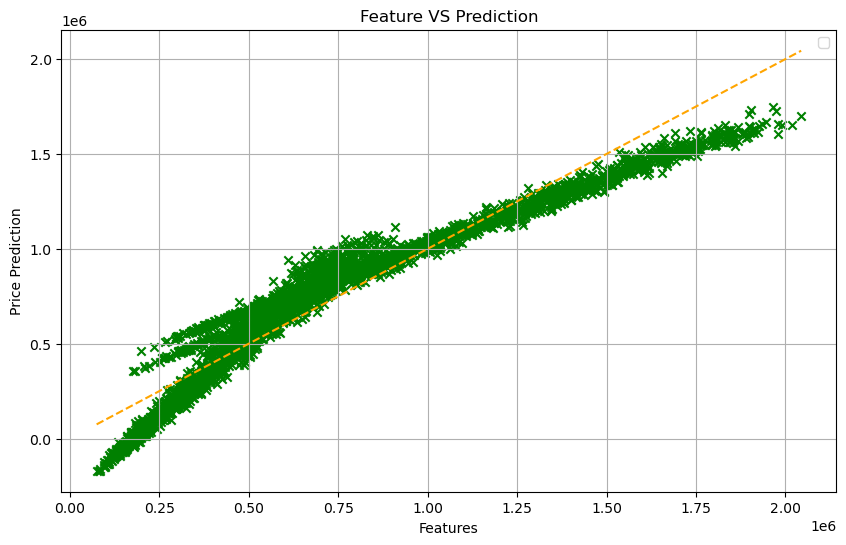

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import  r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import random

#things to define -- location, bedroom, price, water, square_feet, price per square feet
np.random.seed(42)
num_samples = 10000
location = ['Urban','Rural','Suburban']
sim_location = np.random.choice(location,size=num_samples, p = [0.3,0.5,0.2])
bedroom = [1,2,4,3,5]
sim_bed = np.random.choice(bedroom, size=num_samples,p = [0.2,0.2,0.2,0.2,0.2])
water = ['poor','moderate','good']
sim_water = np.random.choice(water,size=num_samples,p=[0.1,0.6,0.3])
error_sq = np.random.normal(loc=0,scale=200,size=num_samples)
sim_sqft = (sim_bed*600) + 300 + error_sq
sim_sqft = np.clip(sim_sqft, 400, 4500).astype(int)
price = {'Urban':500,'Rural':200,'Suburban':450}
sim_price = np.array([price[loc] for loc in sim_location])
pr_noise = np.random.normal(loc=0,scale=15,size=num_samples)
sim_price = (sim_price + (sim_bed*5)+ pr_noise).round(2)
market_price = (sim_sqft*sim_price).round(-3)

df = pd.DataFrame({
    "Location" : sim_location,
    "Bedrooms" : sim_bed,
    "Water_Supply" : sim_water,
    "Square_ft" : sim_sqft,
    "Price" : market_price
})

print(df.head(4))
print(df)
df_enc = pd.get_dummies(df, columns=['Location', 'Water_Supply'], drop_first=True)
scaler = StandardScaler()
x = df_enc.drop('Price',axis=1)
y = df_enc['Price']
x_sc = scaler.fit_transform(x)
x_train,x_test,y_train,y_test = train_test_split(x_sc,y,test_size=0.3,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

print(f"R2 Score : {r2}")
print(f"MSE : {mse}")

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,color='green',marker="x")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='orange',linestyle="--")
plt.xlabel("Features")
plt.ylabel("Price Prediction")
plt.title("Feature VS Prediction")
plt.legend()
plt.grid()
plt.show()

